# Non Anomolous Network Traffic Monitoring

## Agreggating information to the dataset

Uploads: count    885563.000000
mean      10081.351291
std        6920.905624
min          75.000000
25%        5875.000000
50%        9166.000000
75%       13383.000000
max      130665.000000
Name: up_bytes, dtype: float64

Downloads: count    8.855630e+05
mean     9.301665e+04
std      1.455946e+05
min      9.000000e+01
25%      4.692800e+04
50%      7.594800e+04
75%      1.146225e+05
max      1.103284e+07
Name: down_bytes, dtype: float64
Protocols used: ['udp' 'tcp']


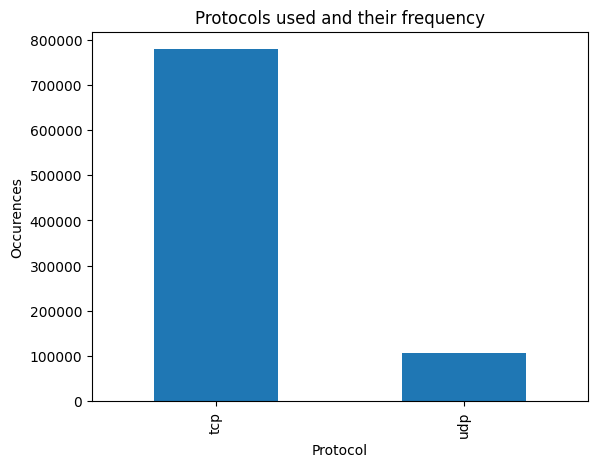

Ports used: [ 53 443]


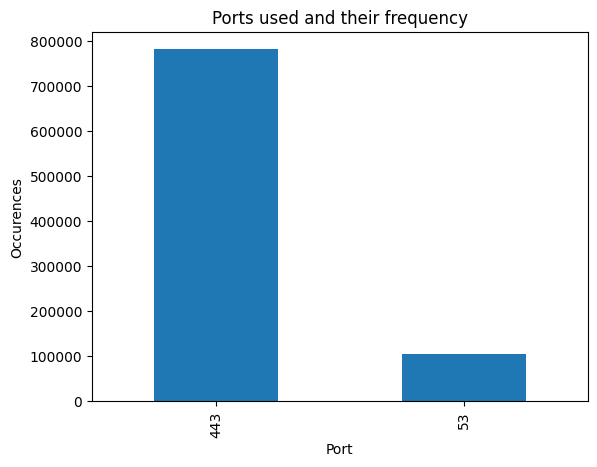

IPs used: ['192.168.101.228' '62.28.254.215' '148.69.168.40' ... '198.199.98.97'
 '97.107.142.40' '143.42.178.229']
No TCP connections on port 53
UDP connections on port 443:         timestamp           src_ip           dst_ip proto  port  up_bytes  \
index                                                                       
758018    1418193  192.168.101.108  142.250.184.156   udp   443     14077   
58683     1438675   192.168.101.49  142.250.184.131   udp   443     12913   
758080    1455931  192.168.101.108  142.250.184.161   udp   443     20008   
758150    1518579  192.168.101.108  142.250.184.175   udp   443     18668   
58849     1524002   192.168.101.49  142.250.184.130   udp   443     26906   
...           ...              ...              ...   ...   ...       ...   
174366    7914167   192.168.101.77  142.250.184.134   udp   443     12123   
527357    8010228  192.168.101.154  142.250.184.196   udp   443     24460   
839373    8049973  192.168.101.152  142.250.184.148   u

In [135]:
import pandas as pd
import numpy as np
import ipaddress
import dns.resolver
import dns.reversename
import pygeoip
import matplotlib.pyplot as plt 

def bytes_to_mb(bytes):
    return bytes / 1000000

def ts_to_hours(ts):
    ts = ts/100
    hours, rem = divmod(ts, 3600)
    minutes, secs = divmod(rem, 60)
    return "{:02}:{:02}:{:02}".format(int(hours), int(minutes), int(secs))

datafile='./../dataset1/data1.parquet'

### Read parquet data files
data = pd.read_parquet(datafile)

print("Uploads: " + str(data['up_bytes'].describe()))
print("\nDownloads: " + str(data['down_bytes'].describe()))

# Check what protocols were used
protocols = data['proto'].unique()
print("Protocols used: " + str(protocols))
data['proto'].value_counts().plot(kind='bar')
plt.title('Protocols used and their frequency')
plt.xlabel('Protocol')
plt.ylabel('Occurences')
plt.show()

# Check what ports were used
ports = data['port'].unique()
print("Ports used: " + str(ports))
data['port'].value_counts().plot(kind='bar')
plt.title('Ports used and their frequency')
plt.xlabel('Port')
plt.ylabel('Occurences')
plt.show()

# Check what IPs were used
ips = data['dst_ip'].unique()
print("IPs used: " + str(ips))

# UDP port 53 --> DNS
# UDP port 443 --> QUIC
# TCP port 443 --> HTTPS

# Verify that port 53 only has UDP connections
tcp53 = data.loc[(data['port'] == 53) & (data['proto'] != 'udp')]
if tcp53.empty:
    print("No TCP connections on port 53")
else:
    print("TCP connections on port 53: " + str(tcp53))

# Verify that port 443 only has TCP connections
udp443 = data.loc[(data['port'] == 443) & (data['proto'] != 'tcp')]
if udp443.empty:
    print("No UDP connections on port 443")
else:
    print("UDP connections on port 443: " + str(udp443))
 
# Add the country code to flow data
gi = pygeoip.GeoIP('./../GeoIP_DBs/GeoIP.dat')
data['dst_cc'] = data['dst_ip'].apply(lambda x: gi.country_code_by_addr(x))

# Check the connections to each country
countries = data['dst_cc'].unique()
print("Countries: " + str(countries))

# Add the organization to flow data
gi2 = pygeoip.GeoIP('./../GeoIP_DBs/GeoIPASNum.dat')
data['dst_org'] = data['dst_ip'].apply(lambda x: gi2.org_by_addr(x))

# Check the connections to each organization
organizations = data['dst_org'].unique()
print("Organizations: " + str(organizations))

# Timestamp to hours
data['ts_in_hours'] = data['timestamp'].apply(lambda x: ts_to_hours(x))

#Is destination IPv4 a public address?
NET=ipaddress.IPv4Network('192.168.101.0/24')
bpublic=data.apply(lambda x: ipaddress.IPv4Address(x['dst_ip']) not in NET,axis=1)

# concat data with cc and org on the collum
data_extra_info = pd.concat([data, data['dst_cc'], data['dst_org'], data['ts_in_hours']], axis=1)


## Non anomolous data analysis

### Internal Communications Analysis

In [136]:
# Flows from internal IPs to internal IPs (192.168.101.X)
internal_flows = data.loc[(data['src_ip'].str.startswith('192.168.101.')) & (data['dst_ip'].str.startswith('192.168.101.'))]

# Number of UDP flows for each source IP (internal flows)
nudpF_internal = internal_flows.loc[internal_flows['proto']=='udp'].groupby(['src_ip']).count()
print("Number of UDP flows for each source IP: " + str(nudpF_internal))

# Number of TCP flows for each source IP (internal flows)
ntcpF_internal = internal_flows.loc[internal_flows['proto']=='tcp'].groupby(['src_ip']).count()
print("Number of TCP flows for each source IP counting upload bytes: " + str(ntcpF_internal))

# Verify which IPs belong to servers (IPs that are private (start with 192.168.101.X) that have more communication, both as source or destination)
src_ips = data.loc[data['src_ip'].str.startswith('192.168.101.')].groupby('src_ip').size().reset_index(name='counts')
dst_ips = data.loc[data['dst_ip'].str.startswith('192.168.101.')].groupby('dst_ip').size().reset_index(name='counts')

# Combine the counts
server_ips = src_ips.set_index('src_ip').add(dst_ips.set_index('dst_ip'), fill_value=0).reset_index().sort_values(by='counts', ascending=False).reset_index(drop=True)

print("Server IPs: " + str(server_ips))


##
# Number of UDP flow to port 53 (DNS), for each source IP (internal flows)
nudpF53_internal = internal_flows.loc[(internal_flows['proto']=='udp')&(internal_flows['port']==53)].groupby(['src_ip']).count()
print("Number of UDP flow to port 53 (DNS), for each source IP, using UDP: " + str(nudpF53_internal))

# Total uploaded bytes to destination port 53 using UDP, for each source IP (internal flows)
upS_internal = internal_flows.loc[((internal_flows['proto']=='udp')&(internal_flows['port']==53))].groupby(['src_ip'])['up_bytes'].sum()
print("Total uploaded bytes to destination port 53 using UDP, for each source IP: " + str(upS_internal))


##
# Number of UDP flows to port 443, for each source IP (internal flows)
nudpF443_internal = internal_flows.loc[(internal_flows['proto']=='udp')&(internal_flows['port']==443)].groupby(['src_ip']).count()
print("Number of UDP flows to port 443 (QUIC), for each source IP, using UDP: " + str(nudpF443_internal))

# Total uploaded bytes to destination port 443 using UDP, for each source IP (internal flows)
upS_internal = internal_flows.loc[((internal_flows['proto']=='udp')&(internal_flows['port']==443))].groupby(['src_ip'])['up_bytes'].sum()
print("Total uploaded bytes to destination port 443 using UDP, for each source IP: " + str(upS_internal))


##
# Number of TCP flows to port 443, for each source IP (internal flows)
ntcpF443_internal = internal_flows.loc[(internal_flows['proto']=='tcp')&(internal_flows['port']==443)].groupby(['src_ip']).count()
print("Number of TCP flows to port 443 (HTTPS), for each source IP, using TCP: " + str(ntcpF443_internal))

# Total uploaded bytes to destination port 443 using TCP, for each source IP (internal flows)
upS_internal = internal_flows.loc[((internal_flows['port']==443))].groupby(['src_ip'])['up_bytes'].sum()
print("Total uploaded bytes to destination port 443, for each source IP: " + str(upS_internal))


##
# Uploaded bytes per flow, for each source IP (internal flows)
upF_internal = internal_flows.groupby(['src_ip'])['up_bytes'].sum()
print("Uploaded bytes per flow, for each source IP: " + str(upF_internal))

# Downloaded bytes per flow, for each source IP (internal flows)
downS_internal = internal_flows.groupby(['src_ip'])['down_bytes'].sum()
print("Downloaded bytes per flow, for each source IP: " + str(downS_internal))


##
# Normal timestamps per source IP flows
ts_internal = internal_flows.groupby(['src_ip'])['timestamp'].mean()
print("Normal timestamps per source IP flows: " + str(ts_internal))

# Check flows per country (internal flows)
cc_internal = internal_flows.groupby(['dst_cc']).count()
print("Flows per country: " + str(cc_internal))

# Check flows per organization (internal flows)
org_internal = internal_flows.groupby(['dst_org']).count()
print("Flows per organization: " + str(org_internal))

Number of UDP flows for each source IP:                  timestamp  dst_ip  proto  port  up_bytes  down_bytes  dst_cc  \
src_ip                                                                          
192.168.101.100        363     363    363   363       363         363     363   
192.168.101.101       1077    1077   1077  1077      1077        1077    1077   
192.168.101.102         81      81     81    81        81          81      81   
192.168.101.103        665     665    665   665       665         665     665   
192.168.101.104        248     248    248   248       248         248     248   
...                    ...     ...    ...   ...       ...         ...     ...   
192.168.101.95         265     265    265   265       265         265     265   
192.168.101.96         277     277    277   277       277         277     277   
192.168.101.97         531     531    531   531       531         531     531   
192.168.101.98         343     343    343   343       343         343

### External Communications Analysis

In [137]:
# Flows from external IPs to external IPs (192.168.101.X)
external_flows = data.loc[(data['src_ip'].str.startswith('192.168.101.')) & (~data['dst_ip'].str.startswith('192.168.101.'))]

# Number of UDP flows for each source IP (external flows)
nudpF_external = external_flows.loc[external_flows['proto']=='udp'].groupby(['src_ip']).count()
print("Number of UDP flows for each source IP: " + str(nudpF_external))

# Number of TCP flows for each source IP (external flows)
ntcpF_external = external_flows.loc[external_flows['proto']=='tcp'].groupby(['src_ip']).count()
print("Number of TCP flows for each source IP counting upload bytes: " + str(ntcpF_external))


##
# Number of UDP flow to port 53 (DNS), for each source IP (external flows)
nudpF53_external = external_flows.loc[(external_flows['proto']=='udp')&(external_flows['port']==53)].groupby(['src_ip']).count()
print("Number of UDP flow to port 53 (DNS), for each source IP, using UDP: " + str(nudpF53_external))

# Total uploaded bytes to destination port 53 using UDP, for each source IP (external flows)
upS_external = external_flows.loc[((external_flows['proto']=='udp')&(external_flows['port']==53))].groupby(['src_ip'])['up_bytes'].sum()
print("Total uploaded bytes to destination port 53 using UDP, for each source IP: " + str(upS_external))


##
# Number of UDP flows to port 443, for each source IP (external flows)
nudpF443_external = external_flows.loc[(external_flows['proto']=='udp')&(external_flows['port']==443)].groupby(['src_ip']).count()
print("Number of UDP flows to port 443 (QUIC), for each source IP, using UDP: " + str(nudpF443_external))

# Total uploaded bytes to destination port 443 using UDP, for each source IP (external flows)
upS_external = external_flows.loc[((external_flows['proto']=='udp')&(external_flows['port']==443))].groupby(['src_ip'])['up_bytes'].sum()
print("Total uploaded bytes to destination port 443 using UDP, for each source IP: " + str(upS_external))


##
# Number of TCP flows to port 443, for each source IP (external flows)
ntcpF443_external = external_flows.loc[(external_flows['proto']=='tcp')&(external_flows['port']==443)].groupby(['src_ip']).count()
print("Number of TCP flows to port 443 (HTTPS), for each source IP, using TCP: " + str(ntcpF443_external))

# Total uploaded bytes to destination port 443 using TCP, for each source IP (external flows)
upS_external = external_flows.loc[((external_flows['port']==443))].groupby(['src_ip'])['up_bytes'].sum()
print("Total uploaded bytes to destination port 443, for each source IP: " + str(upS_external))


##
# Uploaded bytes per flow, for each source IP (external flows)
upF_external = external_flows.groupby(['src_ip'])['up_bytes'].sum()
print("Uploaded bytes per flow, for each source IP: " + str(upF_external))

# Downloaded bytes per flow, for each source IP (external flows)
downS_external = external_flows.groupby(['src_ip'])['down_bytes'].sum()
print("Downloaded bytes per flow, for each source IP: " + str(downS_external))


##
# Normal timestamps per source IP flows
ts_external = external_flows.groupby(['src_ip'])['timestamp'].mean()
print("Normal timestamps per source IP flows: " + str(ts_external))

# Check flows per country (external flows)
cc_external = external_flows.groupby(['dst_cc']).count()
print("Flows per country: " + str(cc_external))

# Check flows per organization (external flows)
org_external = external_flows.groupby(['dst_org']).count()
print("Flows per organization: " + str(org_external))


Number of UDP flows for each source IP:                  timestamp  dst_ip  proto  port  up_bytes  down_bytes  dst_cc  \
src_ip                                                                          
192.168.101.100          9       9      9     9         9           9       9   
192.168.101.101         23      23     23    23        23          23      23   
192.168.101.102          2       2      2     2         2           2       2   
192.168.101.103          9       9      9     9         9           9       9   
192.168.101.104          3       3      3     3         3           3       3   
...                    ...     ...    ...   ...       ...         ...     ...   
192.168.101.95           6       6      6     6         6           6       6   
192.168.101.96           8       8      8     8         8           8       8   
192.168.101.97          17      17     17    17        17          17      17   
192.168.101.98          12      12     12    12        12          12

# Anomolous Network Traffic Monitoring

## Agreggating information to the dataset

Uploads: count    1.132362e+06
mean     2.051585e+04
std      1.682738e+06
min      7.100000e+01
25%      2.920000e+02
50%      7.987000e+03
75%      1.242700e+04
max      4.586658e+08
Name: up_bytes, dtype: float64

Downloads: count    1.132362e+06
mean     7.893879e+04
std      1.373417e+05
min      7.300000e+01
25%      8.190000e+02
50%      6.535900e+04
75%      1.056790e+05
max      8.543258e+06
Name: down_bytes, dtype: float64
Protocols used: 
['udp' 'tcp']


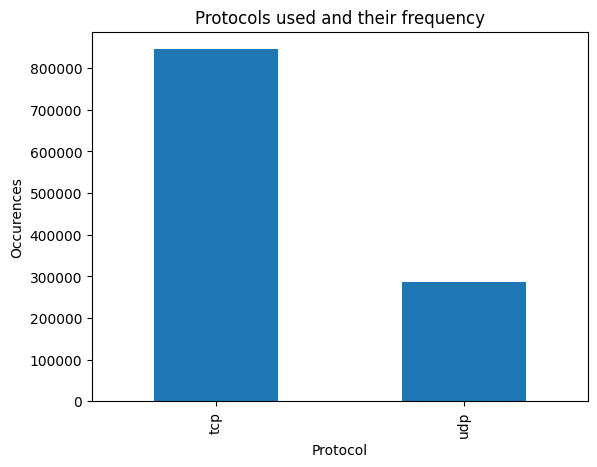

Ports used: 
[ 53 443]


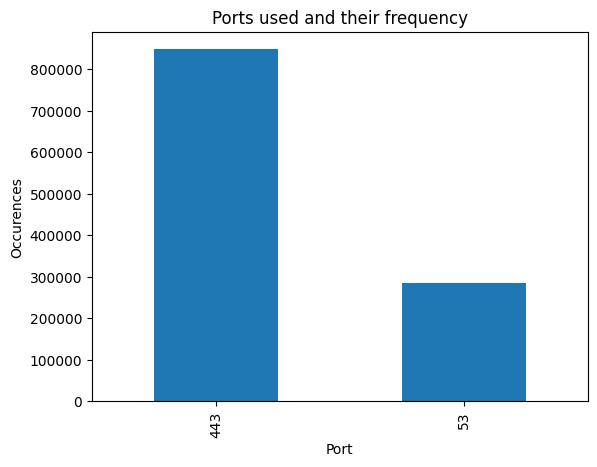

IPs used: ['192.168.101.228' '192.168.101.206' '192.168.101.234' ...
 '52.126.232.139' '52.126.235.39' '150.222.228.30']
No TCP connections on port 53

UDP connections on port 443: 
        timestamp           src_ip           dst_ip proto  port  up_bytes  \
index                                                                       
197800    1224873  192.168.101.160  142.250.184.194   udp   443     33264   
197932    1272901  192.168.101.160  142.250.184.138   udp   443     21156   
584727    1293539   192.168.101.67  142.250.184.244   udp   443     38184   
198091    1327306  192.168.101.160  142.250.184.180   udp   443     16168   
308501    1348820  192.168.101.156  142.250.184.167   udp   443     30438   
...           ...              ...              ...   ...   ...       ...   
253388    8119578  192.168.101.171  142.250.184.139   udp   443     23211   
352700    8149283  192.168.101.187  142.250.184.167   udp   443     28759   
253698    8257557  192.168.101.171  142.250.184.

In [138]:
import pandas as pd
import numpy as np
import ipaddress
import dns.resolver
import dns.reversename
import pygeoip
import matplotlib.pyplot as plt 

def bytes_to_mb(bytes):
    return bytes / 1000000

def ts_to_hours(ts):
    ts = ts/100
    hours, rem = divmod(ts, 3600)
    minutes, secs = divmod(rem, 60)
    return "{:02}:{:02}:{:02}".format(int(hours), int(minutes), int(secs))

testfile='./../dataset1/test1.parquet'

### Read parquet data files
test = pd.read_parquet(testfile)

print("Uploads: " + str(test['up_bytes'].describe()))
print("\nDownloads: " + str(test['down_bytes'].describe()))

# Check what protocols were used
protocols = test['proto'].unique()
print("Protocols used: \n" + str(protocols))
test['proto'].value_counts().plot(kind='bar')
plt.title('Protocols used and their frequency')
plt.xlabel('Protocol')
plt.ylabel('Occurences')
plt.show()

# Check what ports were used
ports = test['port'].unique()
print("Ports used: \n" + str(ports))
test['port'].value_counts().plot(kind='bar')
plt.title('Ports used and their frequency')
plt.xlabel('Port')
plt.ylabel('Occurences')
plt.show()

# Check what IPs were used
ips = test['dst_ip'].unique()
print("IPs used: " + str(ips))

# UDP port 53 --> DNS
# UDP port 443 --> QUIC
# TCP port 443 --> HTTPS

# Verify that port 53 only has UDP connections
tcp53 = test.loc[(test['port'] == 53) & (test['proto'] != 'udp')]
if tcp53.empty:
    print("No TCP connections on port 53\n")
else:
    print("TCP connections on port 53: \n" + str(tcp53))

# Verify that port 443 only has TCP connections
udp443 = test.loc[(test['port'] == 443) & (test['proto'] != 'tcp')]
if udp443.empty:
    print("No UDP connections on port 443\n")
else:
    print("UDP connections on port 443: \n" + str(udp443))
 
# Add the country code to flow test
gi = pygeoip.GeoIP('./../GeoIP_DBs/GeoIP.dat')
test['dst_cc'] = test['dst_ip'].apply(lambda x: gi.country_code_by_addr(x))

# Check the connections to each country
countries = test['dst_cc'].unique()
print("Countries: \n" + str(countries))

# Add the organization to flow test
gi2 = pygeoip.GeoIP('./../GeoIP_DBs/GeoIPASNum.dat')
test['dst_org'] = test['dst_ip'].apply(lambda x: gi2.org_by_addr(x))

# Check the connections to each organization
organizations = test['dst_org'].unique()
print("Organizations: \n" + str(organizations))

# Timestamp to hours
test['ts_in_hours'] = test['timestamp'].apply(lambda x: ts_to_hours(x))

#Is destination IPv4 a public address?
NET=ipaddress.IPv4Network('192.168.101.0/24')
bpublic=test.apply(lambda x: ipaddress.IPv4Address(x['dst_ip']) not in NET,axis=1)

# concat test with cc and org on the collum
test_extra_info = pd.concat([data, data['dst_cc'], data['dst_org'], data['ts_in_hours']], axis=1)


## Anomolous data analysis

### Internal Communications Analysis

In [139]:
# Flows from internal IPs to internal IPs (192.168.101.X)
internal_flows_test = test.loc[(test['src_ip'].str.startswith('192.168.101.')) & (test['dst_ip'].str.startswith('192.168.101.'))]

# Number of UDP flows for each source IP (internal flows)
nudpF_internal_test = internal_flows_test.loc[internal_flows_test['proto']=='udp'].groupby(['src_ip']).count()
print("Number of UDP flows for each source IP: \n" + str(nudpF_internal_test))

# Number of TCP flows for each source IP (internal flows)
ntcpF_internal_test = internal_flows_test.loc[internal_flows_test['proto']=='tcp'].groupby(['src_ip']).count()
print("Number of TCP flows for each source IP counting upload bytes: \n" + str(ntcpF_internal_test))

# Verify which IPs belong to servers (IPs that are private (start with 192.168.101.X) that have more communication, both as source or destination)
src_ips_test = test.loc[test['src_ip'].str.startswith('192.168.101.')].groupby('src_ip').size().reset_index(name='counts')
dst_ips_test = test.loc[test['dst_ip'].str.startswith('192.168.101.')].groupby('dst_ip').size().reset_index(name='counts')

# Combine the counts
server_ips_test = src_ips_test.set_index('src_ip').add(dst_ips_test.set_index('dst_ip'), fill_value=0).reset_index().sort_values(by='counts', ascending=False).reset_index(drop=True)

print("Server IPs: " + str(server_ips_test))


##
# Number of UDP flow to port 53 (DNS), for each source IP (internal flows)
nudpF53_internal_test = internal_flows_test.loc[(internal_flows_test['proto']=='udp')&(internal_flows_test['port']==53)].groupby(['src_ip']).count()
print("Number of UDP flow to port 53 (DNS), for each source IP, using UDP: \n" + str(nudpF53_internal_test))

# Total uploaded bytes to destination port 53 using UDP, for each source IP (internal flows)
upS_internal_test = internal_flows_test.loc[((internal_flows_test['proto']=='udp')&(internal_flows_test['port']==53))].groupby(['src_ip'])['up_bytes'].sum()
print("Total uploaded bytes to destination port 53 using UDP, for each source IP: \n" + str(upS_internal_test))


##
# Number of UDP flows to port 443, for each source IP (internal flows)
nudpF443_internal_test = internal_flows_test.loc[(internal_flows_test['proto']=='udp')&(internal_flows_test['port']==443)].groupby(['src_ip']).count()
print("Number of UDP flows to port 443 (QUIC), for each source IP, using UDP: \n" + str(nudpF443_internal_test))

# Total uploaded bytes to destination port 443 using UDP, for each source IP (internal flows)
upS_internal_test = internal_flows_test.loc[((internal_flows_test['proto']=='udp')&(internal_flows_test['port']==443))].groupby(['src_ip'])['up_bytes'].sum()
print("Total uploaded bytes to destination port 443 using UDP, for each source IP: \n" + str(upS_internal_test))


##
# Number of TCP flows to port 443, for each source IP (internal flows)
ntcpF443_internal_test = internal_flows_test.loc[(internal_flows_test['proto']=='tcp')&(internal_flows_test['port']==443)].groupby(['src_ip']).count()
print("Number of TCP flows to port 443 (HTTPS), for each source IP, using TCP: \n" + str(ntcpF443_internal_test))

# Total uploaded bytes to destination port 443 using TCP, for each source IP (internal flows)
upS_internal_test = internal_flows_test.loc[((internal_flows_test['port']==443))].groupby(['src_ip'])['up_bytes'].sum()
print("Total uploaded bytes to destination port 443, for each source IP: \n" + str(upS_internal_test))


##
# Uploaded bytes per flow, for each source IP (internal flows)
upF_internal_test = internal_flows_test.groupby(['src_ip'])['up_bytes'].sum()
print("Uploaded bytes per flow, for each source IP: \n" + str(upF_internal_test))

# Downloaded bytes per flow, for each source IP (internal flows)
downS_internal_test = internal_flows_test.groupby(['src_ip'])['down_bytes'].sum()
print("Downloaded bytes per flow, for each source IP: \n" + str(downS_internal_test))


##
# Normal timestamps per source IP flows
ts_internal_test = internal_flows_test.groupby(['src_ip'])['timestamp'].mean()
print("Normal timestamps per source IP flows: \n" + str(ts_internal_test))

# Check flows per country (internal flows)
cc_internal_test = internal_flows_test.groupby(['dst_cc']).count()
print("Flows per country: \n" + str(cc_internal_test))

# Check flows per organization (internal flows)
org_internal_test = internal_flows_test.groupby(['dst_org']).count()
print("Flows per organization: \n" + str(org_internal_test))

Number of UDP flows for each source IP: 
                 timestamp  dst_ip  proto  port  up_bytes  down_bytes  dst_cc  \
src_ip                                                                          
192.168.101.100        232     232    232   232       232         232     232   
192.168.101.101        654     654    654   654       654         654     654   
192.168.101.102        676     676    676   676       676         676     676   
192.168.101.103       1248    1248   1248  1248      1248        1248    1248   
192.168.101.104        556     556    556   556       556         556     556   
...                    ...     ...    ...   ...       ...         ...     ...   
192.168.101.94          75      75     75    75        75          75      75   
192.168.101.95         204     204    204   204       204         204     204   
192.168.101.96         597     597    597   597       597         597     597   
192.168.101.98         775     775    775   775       775         77

### External Communications Analysis

In [140]:
# Flows from external IPs to external IPs (192.168.101.X)
external_flows_test = test.loc[(test['src_ip'].str.startswith('192.168.101.')) & (~test['dst_ip'].str.startswith('192.168.101.'))]

# Number of UDP flows for each source IP (external flows)
nudpF_external_test = external_flows_test.loc[external_flows_test['proto']=='udp'].groupby(['src_ip']).count()
print("Number of UDP flows for each source IP: \n" + str(nudpF_external_test))

# Number of TCP flows for each source IP (external flows)
ntcpF_external_test = external_flows_test.loc[external_flows_test['proto']=='tcp'].groupby(['src_ip']).count()
print("Number of TCP flows for each source IP counting upload bytes: \n" + str(ntcpF_external_test))


##
# Number of UDP flow to port 53 (DNS), for each source IP (external flows)
nudpF53_external_test = external_flows_test.loc[(external_flows_test['proto']=='udp')&(external_flows_test['port']==53)].groupby(['src_ip']).count()
print("Number of UDP flow to port 53 (DNS), for each source IP, using UDP: \n" + str(nudpF53_external_test))

# Total uploaded bytes to destination port 53 using UDP, for each source IP (external flows)
upS_external_test = external_flows_test.loc[((external_flows_test['proto']=='udp')&(external_flows_test['port']==53))].groupby(['src_ip'])['up_bytes'].sum()
print("Total uploaded bytes to destination port 53 using UDP, for each source IP: \n" + str(upS_external_test))


##
# Number of UDP flows to port 443, for each source IP (external flows)
nudpF443_external_test = external_flows_test.loc[(external_flows_test['proto']=='udp')&(external_flows_test['port']==443)].groupby(['src_ip']).count()
print("Number of UDP flows to port 443 (QUIC), for each source IP, using UDP: \n" + str(nudpF443_external_test))

# Total uploaded bytes to destination port 443 using UDP, for each source IP (external flows)
upS_external_test = external_flows_test.loc[((external_flows_test['proto']=='udp')&(external_flows_test['port']==443))].groupby(['src_ip'])['up_bytes'].sum()
print("Total uploaded bytes to destination port 443 using UDP, for each source IP: \n" + str(upS_external_test))


##
# Number of TCP flows to port 443, for each source IP (external flows)
ntcpF443_external_test = external_flows_test.loc[(external_flows_test['proto']=='tcp')&(external_flows_test['port']==443)].groupby(['src_ip']).count()
print("Number of TCP flows to port 443 (HTTPS), for each source IP, using TCP: \n" + str(ntcpF443_external_test))

# Total uploaded bytes to destination port 443 using TCP, for each source IP (external flows)
upS_external_test = external_flows_test.loc[((external_flows_test['port']==443))].groupby(['src_ip'])['up_bytes'].sum()
print("Total uploaded bytes to destination port 443, for each source IP: \n" + str(upS_external_test))


##
# Uploaded bytes per flow, for each source IP (external flows)
upF_external_test = external_flows_test.groupby(['src_ip'])['up_bytes'].sum()
print("Uploaded bytes per flow, for each source IP: \n" + str(upF_external_test))

# Downloaded bytes per flow, for each source IP (external flows)
downS_external_test = external_flows_test.groupby(['src_ip'])['down_bytes'].sum()
print("Downloaded bytes per flow, for each source IP: \n" + str(downS_external_test))


##
# Normal timestamps per source IP flows
ts_external_test = external_flows_test.groupby(['src_ip'])['timestamp'].mean()
print("Normal timestamps per source IP flows: \n" + str(ts_external_test))

# Check flows per country (external flows)
cc_external_test = external_flows_test.groupby(['dst_cc']).count()
print("Flows per country: \n" + str(cc_external_test))

# Check flows per organization (external flows)
org_external_test = external_flows_test.groupby(['dst_org']).count()
print("Flows per organization: \n" + str(org_external_test))


Number of UDP flows for each source IP: 
                 timestamp  dst_ip  proto  port  up_bytes  down_bytes  dst_cc  \
src_ip                                                                          
192.168.101.100          5       5      5     5         5           5       5   
192.168.101.101         20      20     20    20        20          20      20   
192.168.101.102         11      11     11    11        11          11      11   
192.168.101.103         20      20     20    20        20          20      20   
192.168.101.104          9       9      9     9         9           9       9   
...                    ...     ...    ...   ...       ...         ...     ...   
192.168.101.94           1       1      1     1         1           1       1   
192.168.101.95           6       6      6     6         6           6       6   
192.168.101.96          11      11     11    11        11          11      11   
192.168.101.98          17      17     17    17        17          1

# Comparing Non Anomolous and Anomolous Network Traffic

## Regular verifications

In [141]:
# Check the used protocols
if (data['proto'].unique() == test['proto'].unique()).all():
    print("Protocols used are the same\n")
else:
    print("The different protocols used are: \n" + str(np.setdiff1d(data['proto'].unique(), test['proto'].unique())))

# Check the used ports
if (data['port'].unique() == test['port'].unique()).all():
    print("Ports used are the same\n")
else:
    print("The different ports used are: \n" + str(np.setdiff1d(data['port'].unique(), test['port'].unique())))


Protocols used are the same

Ports used are the same



## Anomolous verifications

### Server attacks

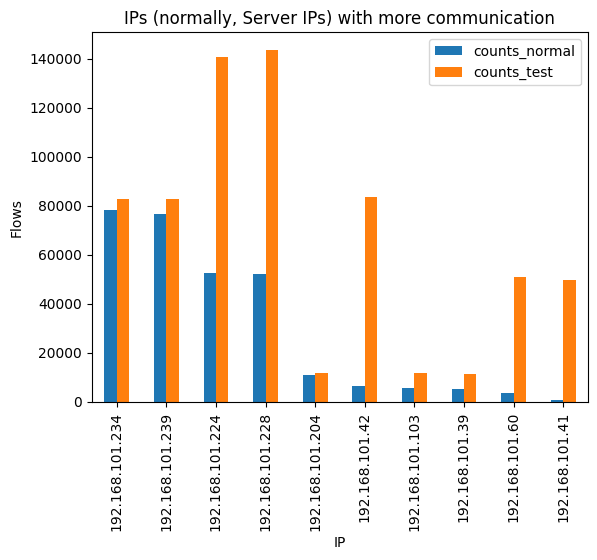

IPs that communicate with the Server IPs and how many flows: 
              src_ip  counts
0    192.168.101.100     900
1    192.168.101.101    2699
2    192.168.101.102     179
3    192.168.101.103    1690
4    192.168.101.104     669
..               ...     ...
191   192.168.101.95     615
192   192.168.101.96     626
193   192.168.101.97    1258
194   192.168.101.98     827
195   192.168.101.99    1190

[196 rows x 2 columns]
IPs that communicate with the "Server IPs" (and others with too traffic) and how many flows (test): 
              src_ip  counts_test
0    192.168.101.100          656
1    192.168.101.101         1673
2    192.168.101.102         1474
3    192.168.101.103         3024
4    192.168.101.104         1296
..               ...          ...
191   192.168.101.94          205
192   192.168.101.95          586
193   192.168.101.96         1381
194   192.168.101.98         1812
195   192.168.101.99         1456

[196 rows x 2 columns]
Increase of communication in perc

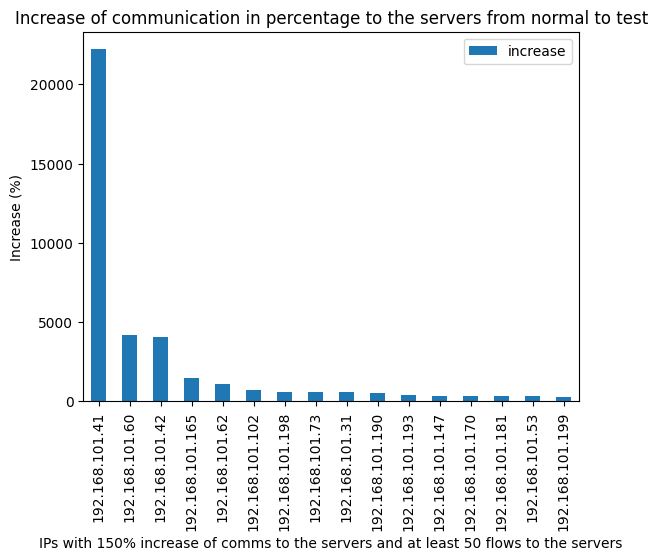

/tmp/ipykernel_7541/1233500090.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timeline_server_attackers['timestamp'] = timeline_server_attackers['timestamp'].apply(lambda x: ts_to_hours(x))


In [142]:
# How the server_ips are obtained
# # Verify which IPs belong to servers (IPs that are private (start with 192.168.101.X) that have more communication, both as source or destination)
# src_ips = data[data['src_ip'].str.startswith('192.168.101.')].groupby('src_ip').size().reset_index(name='counts')
# dst_ips = data[data['dst_ip'].str.startswith('192.168.101.')].groupby('dst_ip').size().reset_index(name='counts')

# server_ips = src_ips.set_index('src_ip').add(dst_ips.set_index('dst_ip'), fill_value=0).reset_index().sort_values(by='counts', ascending=False).reset_index(drop=True)


# How the server_ips_test are obtained
# # Verify which IPs belong to servers (IPs that are private (start with 192.168.101.X) that have more communication, both as source or destination)
# src_ips_test = test[test['src_ip'].str.startswith('192.168.101.')].groupby('src_ip').size().reset_index(name='counts')
# dst_ips_test = test[test['dst_ip'].str.startswith('192.168.101.')].groupby('dst_ip').size().reset_index(name='counts')

# server_ips_test = src_ips_test.set_index('src_ip').add(dst_ips_test.set_index('dst_ip'), fill_value=0).reset_index().sort_values(by='counts', ascending=False).reset_index(drop=True)


# Server IPs differences (top 10 of the most used IPs on test)
top_10_server_ips_test = server_ips_test.head(10)['index'].tolist()
# Filter the normal data for the rows that have the top 10 server IPs of the test
filter_data = server_ips[server_ips['index'].isin(top_10_server_ips_test)]
# Merge to check differences
merge = pd.merge(filter_data, server_ips_test, how='inner', left_on='index', right_on='index', suffixes=('_normal', '_test'))

# Make a plot for this differences (top 10 so that there are some references of normal behaviour)
merge.plot(x='index', y=['counts_normal', 'counts_test'], kind='bar', title="IPs (normally, Server IPs) with more communication", xlabel="IP", ylabel="Flows")
plt.savefig('./../plots/ips_with_more_communication.png')
plt.show()

# Check which IPs normally communicate with the Server IPs and how many flows
server_ips_flows = data.loc[data['dst_ip'].isin(server_ips['index'])].groupby(['src_ip']).size().reset_index(name='counts')
#server_ips_flows = server_ips_flows.sort_values(by='src_ip', ascending=False)
print("IPs that communicate with the Server IPs and how many flows: \n" + str(server_ips_flows))

# Check which IPs communicate with the Server IPs and how many flows (test) and order them by IP
server_ips_flows_test = test.loc[test['dst_ip'].isin(server_ips_test['index'])].groupby(['src_ip']).size().reset_index(name='counts_test')
#server_ips_flows_test = server_ips_flows_test.sort_values(by='src_ip', ascending=False)
print("IPs that communicate with the \"Server IPs\" (and others with too traffic) and how many flows (test): \n" + str(server_ips_flows_test))

# Merge to check differences
possible_server_attackers = pd.merge(server_ips_flows, server_ips_flows_test, how='outer', on='src_ip')

# Fill NaN with 0, since NaN represents no flows aka 0
possible_server_attackers = possible_server_attackers.fillna(0)

# Check the increase of communication in percentage to the servers from normal to test
possible_server_attackers['increase'] = ((possible_server_attackers['counts_test'] - possible_server_attackers['counts']) / possible_server_attackers['counts']) * 100
possible_server_attackers.sort_values(by='increase', ascending=False, inplace=True)
print("Increase of communication in percentage to the servers from normal to test: \n" + str(possible_server_attackers))

## This values need to be justified (and maybe changed)
# Collecting the flows with an increase over 150% or inf, have more than 50 flows to the servers
server_attackers_ips = possible_server_attackers.loc[((possible_server_attackers['increase'] > 250) | (possible_server_attackers['increase'] == np.inf)) & (possible_server_attackers['counts'] > 50)]
print("Possible server attackers IPs that have an increase over 250% or inf, have more than 50 flows to the servers: \n" + str(server_attackers_ips))

# Graph with the increase of communication in percentage to the servers from normal to test
server_attackers_ips.plot(x='src_ip', y='increase', kind='bar', title="Increase of communication in percentage to the servers from normal to test", xlabel="IPs with 150% increase of comms to the servers and at least 50 flows to the servers", ylabel="Increase (%)")
plt.savefig('./../plots/increase_communication_to_servers.png')
plt.show()

# Keeping only the IPs with increase over 500% 
server_attackers_ips = server_attackers_ips.loc[server_attackers_ips['increase'] > 500]

# Check the comms over time of the possible IPs that are attacking the servers
timeline_server_attackers = test.loc[(test['src_ip'].isin(server_attackers_ips['src_ip']))]
timeline_server_attackers['timestamp'] = timeline_server_attackers['timestamp'].apply(lambda x: ts_to_hours(x))

# Isolate things here and analyze them

### Botnet detection

New IPs that are communicating internally: 
['192.168.101.11' '192.168.101.110' '192.168.101.14' '192.168.101.34']
Botnet Suspect IPs that are communicating internally, with which IPs and how many flows: 
             src_ip           dst_ip  counts
0    192.168.101.11  192.168.101.206      28
1    192.168.101.11  192.168.101.224     190
2    192.168.101.11  192.168.101.228     171
3    192.168.101.11  192.168.101.234     312
4    192.168.101.11  192.168.101.239     301
5    192.168.101.11   192.168.101.38      31
6    192.168.101.11   192.168.101.67      24
7    192.168.101.11   192.168.101.85      29
8   192.168.101.110  192.168.101.224     136
9   192.168.101.110  192.168.101.228     117
10  192.168.101.110  192.168.101.234     207
11  192.168.101.110  192.168.101.239     113
12   192.168.101.14  192.168.101.224     142
13   192.168.101.14  192.168.101.228     113
14   192.168.101.14  192.168.101.234     200
15   192.168.101.14  192.168.101.239     166
16   192.168.101.34  192.168.1

/tmp/ipykernel_7541/4108245331.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bot_34['timestamp'] = bot_34['timestamp'].apply(lambda x: ts_to_hours(x))


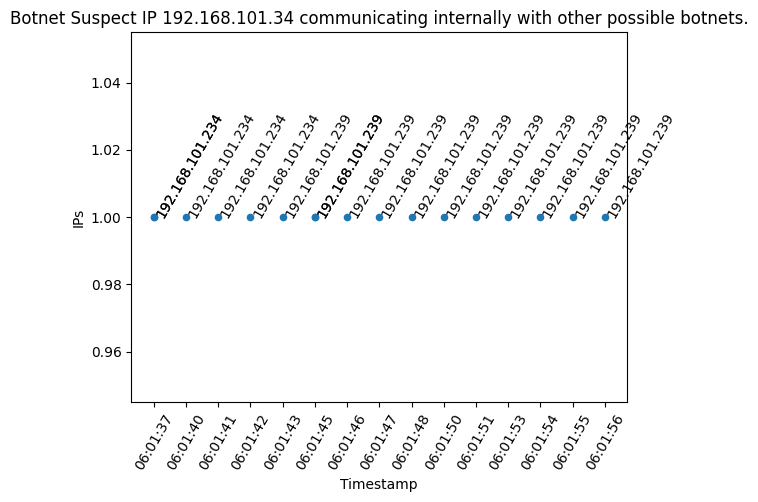

In [170]:
############### BOTNET SUSPECTS ###############

# Having internal_flows and internal_flows_test from the previous cells, we can check new IPs that are communicating internally
# Check the new IPs that are communicating internally
botnet_suspects_ips = np.setdiff1d(internal_flows_test['src_ip'].unique(), internal_flows['src_ip'].unique())
print("New IPs that are communicating internally: \n" + str(botnet_suspects_ips))

# Check if the botnet_suspect_ips are communicating with the other botnet_suspect_ips
botnet_suspects_ips_flows = internal_flows_test[internal_flows_test['src_ip'].isin(botnet_suspects_ips)]
botnet_suspects_ips_flows = botnet_suspects_ips_flows.groupby(['src_ip', 'dst_ip']).size().reset_index(name='counts')
print("Botnet Suspect IPs that are communicating internally, with which IPs and how many flows: \n" + str(botnet_suspects_ips_flows))

# Check the Protocol and Port of the between the botnet_suspect_ips and the IPs they communicate with
botnet_suspects_ips_flows_proto_port = internal_flows_test[internal_flows_test['src_ip'].isin(botnet_suspects_ips)]
botnet_suspects_ips_flows_proto_port = botnet_suspects_ips_flows_proto_port.groupby(['src_ip', 'dst_ip', 'proto', 'port']).size().reset_index(name='counts')
print("Botnet Suspect IPs that are communicating internally, with which IPs, how many flows, and the protocol and port: \n" + str(botnet_suspects_ips_flows_proto_port))

# # Get the timeline from test from the 192.168.101.11 to the other botnet_suspects_ips
# bot_11 = test.loc[(test['src_ip'] == '192.168.101.11') & (test['dst_ip'].isin(botnet_suspects_ips_flows['dst_ip']))]
# # Add timestamp column
# bot_11['timestamp'] = bot_11['timestamp'].apply(lambda x: ts_to_hours(x))

# # Get the timeline from test from the 192.168.101.110 to the other botnet_suspects_ips
# bot_110 = test.loc[(test['src_ip'] == '192.168.101.110') & (test['dst_ip'].isin(botnet_suspects_ips_flows['dst_ip']))]
# # Add timestamp column
# bot_110['timestamp'] = bot_110['timestamp'].apply(lambda x: ts_to_hours(x))

# # Get the timeline from test from the 192.168.101.14 to the other botnet_suspects_ips
# bot_14 = test.loc[(test['src_ip'] == '192.168.101.14') & (test['dst_ip'].isin(botnet_suspects_ips_flows['dst_ip']))]
# # Add timestamp column
# bot_14['timestamp'] = bot_14['timestamp'].apply(lambda x: ts_to_hours(x))

# Get the timeline from test from the 192.168.101.34 to the other botnet_suspects_ips
bot_34 = test.loc[(test['src_ip'] == '192.168.101.34') & (test['dst_ip'].isin(botnet_suspects_ips_flows['dst_ip']))]
# Add timestamp column
bot_34['timestamp'] = bot_34['timestamp'].apply(lambda x: ts_to_hours(x))

# Get the first 15 lines of the timeline from test
# bot_11[['src_ip', 'dst_ip', 'timestamp']].head(15).reset_index(drop=True)
# bot_110[['src_ip', 'dst_ip', 'timestamp']].head(15).reset_index(drop=True)
# bot_14[['src_ip', 'dst_ip', 'timestamp']].head(15).reset_index(drop=True)
bot_34[['src_ip', 'dst_ip', 'timestamp']].head(15).reset_index(drop=True)

# Keep the timestamp between 04:00:00 and 04:30:00
# bot_11 = bot_11.loc[(bot_11['timestamp'] >= '00:00:00') & (bot_11['timestamp'] <= '07:30:00')]
# bot_110 = bot_110.loc[(bot_110['timestamp'] >= '00:00:00') & (bot_110['timestamp'] <= '07:30:00')]
# bot_14 = bot_14.loc[(bot_14['timestamp'] >= '00:00:00') & (bot_14['timestamp'] <= '07:30:00')]
bot_34 = bot_34.loc[(bot_34['timestamp'] >= '06:00:00') & (bot_34['timestamp'] <= '06:02:00')]

# Ignore this :D
# bot_11['count'] = 1
# bot_110['count'] = 1
# bot_14['count'] = 1
bot_34['count'] = 1

# Make a scatter plot
# bot_11.plot.scatter(x='timestamp', y='count', title="Botnet Suspect IPs that are communicating internally between them.", xlabel="Timestamp", ylabel="IPs")
# plt.savefig('./../plots/bot_11_botnet_suspects_ips_communicating_internally.png')
# plt.show()

# bot_110.plot.scatter(x='timestamp', y='count', title="Botnet Suspect IPs that are communicating internally between them.", xlabel="Timestamp", ylabel="IPs")
# plt.savefig('./../plots/bot_110_botnet_suspects_ips_communicating_internally.png')
# plt.show()

# bot_14.plot.scatter(x='timestamp', y='count', title="Botnet Suspect IPs that are communicating internally between them.", xlabel="Timestamp", ylabel="IPs")
# plt.savefig('./../plots/bot_14_botnet_suspects_ips_communicating_internally.png')
# plt.show()

bot_34.plot(x='timestamp', y='count', kind='scatter', title="Botnet Suspect IP 192.168.101.34 communicating internally with other possible botnets.", xlabel="Timestamp", ylabel="IPs")
plt.xticks(rotation=60)
# put the dst_ip over the points
for i, txt in enumerate(bot_34['dst_ip']):
    plt.annotate(txt, (bot_34['timestamp'].iloc[i], bot_34['count'].iloc[i]), rotation=60, fontsize=10)
plt.savefig('./../plots/bot_34_botnet_suspects_ips_communicating_internally.png')
plt.show()



### Anomolous External Activity - Data Exfiltration

In [188]:
# Having already external_flows_test, we can check new IPs that are communicating externally and how much down_bytes and up_bytes they have
# Check the new IPs that are communicating externally
internet_suspect_ips = np.setdiff1d(external_flows_test['src_ip'].unique(), external_flows['src_ip'].unique())
print("New IPs that are communicating externally: \n" + str(internet_suspect_ips))

exterior_suspect_ips = np.setdiff1d(external_flows_test['dst_ip'].unique(), external_flows['dst_ip'].unique())
print("New IPs that are communicating from the exterior: \n" + str(exterior_suspect_ips))

# Check the down_bytes and up_bytes of the internet_suspects_ips using from_bytes_to_mb()
internet_suspects_ips_bytes = external_flows_test[external_flows_test['src_ip'].isin(internet_suspect_ips)]
internet_suspects_ips_down_bytes = internet_suspects_ips_bytes.groupby(['src_ip'])['down_bytes'].sum().apply(lambda x: bytes_to_mb(x))
internet_suspects_ips_up_bytes = internet_suspects_ips_bytes.groupby(['src_ip'])['up_bytes'].sum().apply(lambda x: bytes_to_mb(x))
print("Internet Suspect IPs that are communicating externally and DOWNLOADING how much MBytes: \n" + str(internet_suspects_ips_down_bytes) + "\n" + 
      "Internet Suspect IPs that are communicating externally and UPLOADING how much MBytes:\n" + str(internet_suspects_ips_up_bytes))

# Check which public IPs are they accessing
suspect_public_ips = internet_suspects_ips_bytes.groupby(['src_ip', 'dst_ip', 'proto', 'port']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)
print("Internet Suspect IPs that are communicating externally, with the public IPs: \n" + str(suspect_public_ips))

# Check which Country and Organization they are accessing
suspect_public_ips_cc_org = internet_suspects_ips_bytes.groupby(['src_ip', 'dst_ip', 'dst_cc', 'dst_org']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)
print("Internet Suspect IPs that are communicating externally, with the public IPs, and the Country and Organization: \n" + str(suspect_public_ips_cc_org))

# Check the number of flows for each source IP (external flows)
info_outside_normal = external_flows.groupby(['src_ip', 'dst_ip']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)

# Check the number of flows for each source IP (external flows of test)
info_outside_test = external_flows_test.groupby(['src_ip', 'dst_ip']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)

# Merge to check differences
info_outside = pd.merge(info_outside_normal, info_outside_test, on=['src_ip', 'dst_ip'], how='right')

# Percentage of increase of communication to the exterior
info_outside['increase'] = ((info_outside['counts_y'] - info_outside['counts_x']) / info_outside['counts_x']) * 100

# Keep the ones with increase > 150% or inf, and have more than 50 flows
info_outside = info_outside[((info_outside['increase'] > 150) | (info_outside['increase'] == np.inf)) & (info_outside['counts_y'] > 50)] 

# Maybe should conclude something else or smtg at all here

## Data Exfiltration

# Check the number of bytes uploaded 
normal_up = data.loc[(data['dst_ip']).str.startswith('192.168.101.')].groupby(['src_ip'])['up_bytes'].sum().reset_index(name='up_bytes')
# Check the number of flows to the internet
normal_flows = data.loc[(data['dst_ip']).str.startswith('192.168.101.')].groupby(['src_ip']).size().reset_index(name='counts')

# Check the number of bytes uploaded - test
test_up = test.loc[(test['dst_ip']).str.startswith('192.168.101.')].groupby(['src_ip'])['up_bytes'].sum().reset_index(name='up_bytes')
# Check the number of flows to the internet - test
test_flows = test.loc[(test['dst_ip']).str.startswith('192.168.101.')].groupby(['src_ip']).size().reset_index(name='counts')

# Average uploaded bytes per flow
normal_up = pd.merge(normal_up, normal_flows, on='src_ip', how='inner')
normal_up['avg_up_bytes'] = normal_up['up_bytes'] / normal_flows['counts']
# Average uploaded bytes per flow - test
test_up = pd.merge(test_up, test_flows, on='src_ip', how='inner')
test_up['avg_up_bytes'] = test_up['up_bytes'] / test_flows['counts']

# Merge to check differences -- Only increases of 50% or more
up_bytes = pd.merge(normal_up, test_up, on='src_ip', how='inner')
up_bytes = up_bytes[(up_bytes['avg_up_bytes_y'] > (up_bytes['avg_up_bytes_x']*1.5))]

# Extract the destination IP where the up_bytes IP is communicating with
exfilt = data.loc[(data['src_ip'].isin(up_bytes['src_ip'])) & (data['dst_ip'].str.startswith('192.168.101.'))]
exfilt = exfilt[['src_ip', 'dst_ip']]
# Add country and org
exfilt['dst_cc'] = exfilt['dst_ip'].apply(lambda x: gi.country_code_by_addr(x))
exfilt['dst_org'] = exfilt['dst_ip'].apply(lambda x: gi2.org_by_addr(x))

# From the exfilt, check the uploaded bytes to the internet (dst_ip not starting with 192.168.101.) from the src_ips there
exfilt_up = test.loc[(test['src_ip'].isin(exfilt['src_ip'])) & (~test['dst_ip'].str.startswith('192.168.101.'))].groupby(['src_ip'])['up_bytes'].sum().reset_index(name='up_bytes_exfiltered')
# The same for test dataset
exfilt_up['up_bytes_normal'] = data.loc[(data['src_ip'].isin(exfilt['src_ip'])) & (~data['dst_ip'].str.startswith('192.168.101.'))].groupby(['src_ip'])['up_bytes'].sum().reset_index(name='up_bytes_normal')['up_bytes_normal']

# Add the increase in percentage
exfilt_up['increase'] = ((exfilt_up['up_bytes_exfiltered'] - exfilt_up['up_bytes_normal']) / exfilt_up['up_bytes_normal']) * 100

# Remove the ones who transmitted less than 500MB
exfilt_up_500MB = exfilt_up[exfilt_up['up_bytes_exfiltered'] > 500000000]

# Check who this source IP has communications with
exfilt_500MB = test.loc[(test['src_ip'].isin(exfilt_up_500MB['src_ip'])) & (~test['dst_ip'].str.startswith('192.168.101.'))]
# Add country and org
exfilt_500MB['dst_cc'] = exfilt_500MB['dst_ip'].apply(lambda x: gi.country_code_by_addr(x))
exfilt_500MB['dst_org'] = exfilt_500MB['dst_ip'].apply(lambda x: gi2.org_by_addr(x))

# Join the pairs src_ip - dst_ip with number of flows
exfilt_500MB = exfilt_500MB.groupby(['src_ip', 'dst_ip']).size().reset_index(name='counts')

# Get the uploaded bytes from the pairs (src_ip - dst_ip)
_upload_bytes = test.loc[(test['src_ip'].isin(exfilt_500MB['src_ip'])) & (test['dst_ip'].isin(exfilt_500MB['dst_ip']))].groupby(['src_ip', 'dst_ip'])['up_bytes'].sum().reset_index(name='up_bytes')
# Merge the info about exfiltration
exfilt_500MB = pd.merge(exfilt_500MB, _upload_bytes, on=['src_ip', 'dst_ip'], how='inner')


New IPs that are communicating externally: 
['192.168.101.11' '192.168.101.110' '192.168.101.14' '192.168.101.34']
New IPs that are communicating from the exterior: 
['1.12.170.41' '101.194.64.156' '101.203.185.141' ... '99.83.117.88'
 '99.83.118.228' '99.83.118.23']
Internet Suspect IPs that are communicating externally and DOWNLOADING how much MBytes: 
src_ip
192.168.101.11     243.544328
192.168.101.110    175.307206
192.168.101.14     178.175953
192.168.101.34     408.718135
Name: down_bytes, dtype: float64
Internet Suspect IPs that are communicating externally and UPLOADING how much MBytes:
src_ip
192.168.101.11     26.886369
192.168.101.110    17.637547
192.168.101.14     19.224540
192.168.101.34     43.129404
Name: up_bytes, dtype: float64
Internet Suspect IPs that are communicating externally, with the public IPs: 
             src_ip           dst_ip proto  port  counts
436  192.168.101.34    172.217.17.14   tcp   443     272
38   192.168.101.11   142.250.200.68   tcp   443   

### Country statistics analysis

In [189]:
# Number of flows to each country
country_info = data.loc[~(data['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc']).size().reset_index(name='counts')
# Number of uploaded and downloaded bytes
country_info['up_bytes'] = data.loc[~(data['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['up_bytes'].sum().reset_index(name='up_bytes')['up_bytes']
country_info['down_bytes'] = data.loc[~(data['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['down_bytes'].sum().reset_index(name='down_bytes')['down_bytes']

# Make the mean, standard deviation, min and max of the up_bytes and down_bytes
country_info['up_bytes_mean'] = data.loc[~(data['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['up_bytes'].mean().reset_index(name='up_bytes_mean')['up_bytes_mean']
country_info['up_bytes_std'] = data.loc[~(data['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['up_bytes'].std().reset_index(name='up_bytes_std')['up_bytes_std']
country_info['up_bytes_min'] = data.loc[~(data['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['up_bytes'].min().reset_index(name='up_bytes_min')['up_bytes_min']
country_info['up_bytes_max'] = data.loc[~(data['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['up_bytes'].max().reset_index(name='up_bytes_max')['up_bytes_max']

country_info['down_bytes_mean'] = data.loc[~(data['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['down_bytes'].mean().reset_index(name='down_bytes_mean')['down_bytes_mean']
country_info['down_bytes_std'] = data.loc[~(data['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['down_bytes'].std().reset_index(name='down_bytes_std')['down_bytes_std']
country_info['down_bytes_min'] = data.loc[~(data['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['down_bytes'].min().reset_index(name='down_bytes_min')['down_bytes_min']
country_info['down_bytes_max'] = data.loc[~(data['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['down_bytes'].max().reset_index(name='down_bytes_max')['down_bytes_max']


# The same for test
country_info_test = test.loc[~(test['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc']).size().reset_index(name='counts')
country_info_test['up_bytes'] = test.loc[~(test['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['up_bytes'].sum().reset_index(name='up_bytes')['up_bytes']
country_info_test['down_bytes'] = test.loc[~(test['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['down_bytes'].sum().reset_index(name='down_bytes')['down_bytes']

# Make the mean, standard deviation, min and max of the up_bytes and down_bytes
country_info_test['up_bytes_mean'] = test.loc[~(test['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['up_bytes'].mean().reset_index(name='up_bytes_mean')['up_bytes_mean']
country_info_test['up_bytes_std'] = test.loc[~(test['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['up_bytes'].std().reset_index(name='up_bytes_std')['up_bytes_std']
country_info_test['up_bytes_min'] = test.loc[~(test['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['up_bytes'].min().reset_index(name='up_bytes_min')['up_bytes_min']
country_info_test['up_bytes_max'] = test.loc[~(test['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['up_bytes'].max().reset_index(name='up_bytes_max')['up_bytes_max']

country_info_test['down_bytes_mean'] = test.loc[~(test['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['down_bytes'].mean().reset_index(name='down_bytes_mean')['down_bytes_mean']
country_info_test['down_bytes_std'] = test.loc[~(test['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['down_bytes'].std().reset_index(name='down_bytes_std')['down_bytes_std']
country_info_test['down_bytes_min'] = test.loc[~(test['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['down_bytes'].min().reset_index(name='down_bytes_min')['down_bytes_min']
country_info_test['down_bytes_max'] = test.loc[~(test['dst_ip']).str.startswith('192.168.101.')].groupby(['dst_cc'])['down_bytes'].max().reset_index(name='down_bytes_max')['down_bytes_max']

# Merge data information with test
country_diff = pd.merge(country_info, country_info_test, on='dst_cc', how='right')
country_diff = country_diff.fillna(0)

# Remove the ones that have less than 50 flows and that have a smaller increase than 50% between country_info_flows and country_info_test_flows 
# and that have less than a 20% increase in up_bytes/flows and down_bytes/flows
country_diff = country_diff[(country_diff['counts_y'] > 50) & (country_diff['up_bytes_mean_y'] > (country_diff['up_bytes_mean_x']*1.2)) & (country_diff['down_bytes_mean_y'] > (country_diff['down_bytes_mean_x']*1.2))]